# Lab: Practical AI Model Deployment with TensorFlow Lite

In this notebook, our team trained an MNIST digit classifier, converted it to TensorFlow Lite, and validated inference with the TFLite Interpreter.

## Part 1: Setting Up the Development Environment

### Step 1: Verify Python and TensorFlow Installation

In [1]:
!python --version
!pip show tensorflow

Python 3.10.16
Name: tensorflow
Version: 2.15.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /Users/martin.demel/myenv3.10/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: tensorflow-macos, tf_keras


### Step 2: Install TensorFlow and Jupyter Notebook

In [2]:
!pip install --upgrade pip
!pip install "tensorflow==2.15.1"

!pip install jupyter

## Part 2: Creating and Training an AI Model

In this section, we loaded and normalized the MNIST dataset, visualized sample digits, trained a small neural network, and saved the trained model to disk.

### Step 3: Load the MNIST Dataset

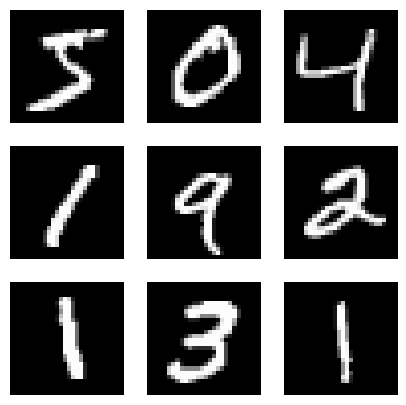

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Show sample images
plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.show()


### Step 4: Define and Train a Neural Network

In this step, we built a simple feedforward network for digit classification. We trained it for 5 epochs, evaluated accuracy, and saved the model as `mnist_model.h5` for conversion.

In [4]:
# Define model architecture
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Optional: evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Save trained model
model.save("mnist_model.h5")
print("Model training complete and saved as mnist_model.h5")


2026-01-28 14:25:02.308084: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-01-28 14:25:02.308110: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-01-28 14:25:02.308116: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-01-28 14:25:02.308148: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-28 14:25:02.308162: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5
   8/1875 [..............................] - ETA: 14s - loss: 2.0782 - accuracy: 0.2422 

2026-01-28 14:25:02.670681: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 [==============================] - 14s 7ms/step - loss: 0.3650 - accuracy: 0.8967 - val_loss: 0.2983 - val_accuracy: 0.9146
Epoch 2/5
1875/1875 [==============================] - 14s 7ms/step - loss: 0.3103 - accuracy: 0.9143 - val_loss: 0.3107 - val_accuracy: 0.9150
Epoch 3/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3161 - accuracy: 0.9142 - val_loss: 0.3154 - val_accuracy: 0.9145
Epoch 4/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3284 - accuracy: 0.9114 - val_loss: 0.3138 - val_accuracy: 0.9162
Epoch 5/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3391 - accuracy: 0.9108 - val_loss: 0.3635 - val_accuracy: 0.9067
Test accuracy: 0.9067
Model training complete and saved as mnist_model.h5


/Users/martin.demel/myenv3.10/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Part 3: Converting and Saving the Model

### Step 5: Convert the Model to TensorFlow Lite Format

Here, we loaded the trained model, ran the TensorFlow Lite converter, and saved the output as `mnist_model.tflite`.

In [5]:
# Load trained model
model = tf.keras.models.load_model("mnist_model.h5")

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model successfully converted and saved as mnist_model.tflite")


INFO:tensorflow:Assets written to: /var/folders/m_/nqk8g4cs5tz8t1yj2kglt8p80000gn/T/tmpkjfw6gbx/assets


INFO:tensorflow:Assets written to: /var/folders/m_/nqk8g4cs5tz8t1yj2kglt8p80000gn/T/tmpkjfw6gbx/assets


Model successfully converted and saved as mnist_model.tflite


2026-01-28 14:26:10.743501: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-01-28 14:26:10.743520: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-01-28 14:26:10.743696: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/m_/nqk8g4cs5tz8t1yj2kglt8p80000gn/T/tmpkjfw6gbx
2026-01-28 14:26:10.744114: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-01-28 14:26:10.744118: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/m_/nqk8g4cs5tz8t1yj2kglt8p80000gn/T/tmpkjfw6gbx
2026-01-28 14:26:10.744945: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-01-28 14:26:10.745257: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-01-28 14:26:10.760283: I tensorflow/cc/saved_model/loader.

## Part 4: Loading and Running Inference with TensorFlow Lite

### Step 6: Load the Converted Model Using the TensorFlow Lite Interpreter

In this step, we initialized the interpreter for `mnist_model.tflite`, allocated tensors, and printed the input/output tensor details.

In [6]:
# Load TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:", input_details)
print("Output Details:", output_details)


Input Details: [{'name': 'serving_default_flatten_input:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### Step 7: Perform Inference with TensorFlow Lite

Finally, we ran inference on one MNIST test image and visualized the predicted label alongside the true label.

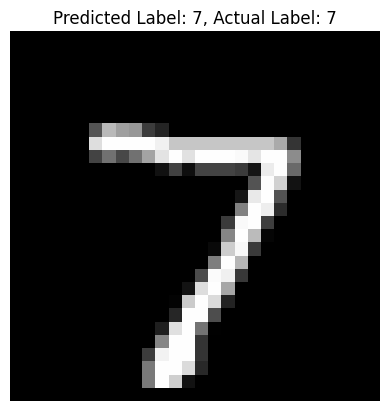

In [7]:
# Select a test image
test_image = x_test[0].astype(np.float32)
test_image = np.expand_dims(test_image, axis=0)

# Set the input tensor
interpreter.set_tensor(input_details[0]['index'], test_image)

# Run inference
interpreter.invoke()

# Get the prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Display the image and prediction
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted Label: {predicted_label}, Actual Label: {y_test[0]}")
plt.axis("off")
plt.show()
